# Grad-CAM check -- DenseNet-121 & ResNet-50, simple head, original vs. cropped

Same data pipeline as `Basic_CNN_model.ipynb` through hair removal and cropping,
then a deliberately **simple** setup instead of the full model comparison there:

- Both backbones frozen (ImageNet weights, never fine-tuned) with the same simple
  head (`Dropout(0.2) -> Dense(1, sigmoid)`) as that notebook's own baseline
  sections -- no MLP head, no Phase 2 fine-tuning.
- Trained once on **original** images and once on **cropped** images, per backbone
  -- 4 models total -- so Grad-CAM can compare what each backbone focuses on
  before vs. after boundary-localization cropping.
- Grad-CAM is run only over the **malignant images in the validation (test) split**
  for each of the 4 models, and every overlay gets saved to disk, zipped, and
  copied to Google Drive.

Since both backbones are frozen, the conv feature maps Grad-CAM reads from are
fully deterministic for a given image -- only the trained head's weights (and
therefore which channels the heatmap weights most) can vary between runs, and
that's pinned down too by the `SEED`/`enable_op_determinism()` setup below. The
one thing that legitimately changes the heatmap here is feeding in different
pixels -- original vs. cropped -- which is exactly what this notebook compares.

In [30]:
import os
import random

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import tensorflow as tf

# Fix every source of randomness up front -- see Basic_CNN_model.ipynb for the
# full reasoning. TensorFlow's own RNG (Dense-layer weight init) and GPU op-level
# determinism need pinning separately from numpy/sklearn's per-call seeds below.
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
tf.config.experimental.enable_op_determinism()

## (Colab only) Unpack data from Google Drive

Running on a local kernel, `train/` and `train_labels.csv` already sit next to this
notebook. Running on a **Colab kernel**, upload `melanoma_data.zip` to your Google
Drive once, then this cell mounts your Drive and unzips it into `/content` each
session. No-op when there's no Colab runtime.

In [31]:
import os

if os.path.isdir('/content'):
    os.chdir('/content')
    if not os.path.isdir('train'):
        DRIVE_ZIP_PATH = '/content/drive/MyDrive/melanoma_data.zip'  # adjust if you put it elsewhere in Drive

        from google.colab import drive
        drive.mount('/content/drive')

        zip_source = DRIVE_ZIP_PATH if os.path.exists(DRIVE_ZIP_PATH) else 'melanoma_data.zip'
        assert os.path.exists(zip_source), (
            f"Couldn't find the data zip at {DRIVE_ZIP_PATH} or /content/melanoma_data.zip -- "
            "upload melanoma_data.zip to your Google Drive (or directly to Colab) first"
        )
        get_ipython().system(f'unzip -q "{zip_source}"')
    print('data ready in', os.getcwd())

data ready in /content


In [32]:
# VS Code's Jupyter extension can run this notebook with the *workspace root* as
# the working directory instead of this notebook's own folder, which breaks every
# relative path below. __vsc_ipynb_file__ (injected by the VS Code Jupyter
# extension) gives this notebook's own absolute path -- hop into its folder if
# we're not already there and we're not on Colab (which manages /content above).
_nb_path = globals().get('__vsc_ipynb_file__')
if _nb_path and not os.path.isdir('/content'):
    os.chdir(os.path.dirname(_nb_path))

print('working directory:', os.getcwd())

working directory: /content


## Reading files

In [33]:
import os
import pandas as pd

TRAIN_DIR = 'train'

train_files = sorted(f for f in os.listdir(TRAIN_DIR) if f.lower().endswith('.jpg'))
files_df = pd.DataFrame({
    'image_name': [os.path.splitext(f)[0] for f in train_files],
    'image_path': [os.path.join(TRAIN_DIR, f) for f in train_files],
})

print(f'{len(files_df)} jpg files found in {TRAIN_DIR}/')
files_df.head()

6864 jpg files found in train/


,image_name,image_path
0,ISIC_0015719,train/ISIC_0015719.jpg
1,ISIC_0074542,train/ISIC_0074542.jpg
2,ISIC_0076545,train/ISIC_0076545.jpg
3,ISIC_0082348,train/ISIC_0082348.jpg
4,ISIC_0085172,train/ISIC_0085172.jpg


In [34]:
labels_df = pd.read_csv('train_labels.csv')

data_df = files_df.merge(labels_df, on='image_name', how='inner')

print(f'{len(data_df)} images matched to a label (of {len(files_df)} files, {len(labels_df)} label rows)')
data_df.shape

6864 images matched to a label (of 6864 files, 6864 label rows)


(6864, 9)

## Image-only dataset (image_name, patient_id, image_path, target)

In [35]:
image_df = data_df[['image_name', 'patient_id', 'image_path', 'target']].copy()
image_df.head()

,image_name,patient_id,image_path,target
0,ISIC_0015719,IP_3075186,train/ISIC_0015719.jpg,0
1,ISIC_0074542,IP_4698288,train/ISIC_0074542.jpg,0
2,ISIC_0076545,IP_9802602,train/ISIC_0076545.jpg,0
3,ISIC_0082348,IP_7684360,train/ISIC_0082348.jpg,0
4,ISIC_0085172,IP_1705144,train/ISIC_0085172.jpg,0


## Hair removal (DullRazor)

Same as `Basic_CNN_model.ipynb` -- needed as the input the cropping step below
runs on, even though the "original" images used further down are the
*pre*-hair-removal images straight from `train/`.

In [36]:
import cv2


def remove_hair(img_rgb, kernel_size=9, inpaint_radius=6, thresh=10):
    """
    DullRazor-style hair removal: a blackhat morphological filter highlights
    dark, thin, hair-like structures against the surrounding skin; those pixels
    are thresholded into a mask, and cv2.inpaint fills them back in using the
    surrounding (hair-free) pixels.
    """
    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    kernel = cv2.getStructuringElement(cv2.MORPH_CROSS, (kernel_size, kernel_size))
    blackhat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel)
    blurred = cv2.GaussianBlur(blackhat, (3, 3), cv2.BORDER_DEFAULT)
    _, hair_mask = cv2.threshold(blurred, thresh, 255, cv2.THRESH_BINARY)
    return cv2.inpaint(img_rgb, hair_mask, inpaint_radius, cv2.INPAINT_TELEA)

### Cache hair-removed images (skip re-running DullRazor every session)

In [37]:
import shutil
import zipfile

HAIRLESS_DIR = 'train_hairless'
HAIRLESS_ZIP = 'melanoma_hairless.zip'
DRIVE_HAIRLESS_ZIP = '/content/drive/MyDrive/melanoma_hairless.zip'

if not os.path.isdir(HAIRLESS_DIR):
    cached_zip = next((z for z in (HAIRLESS_ZIP, DRIVE_HAIRLESS_ZIP) if os.path.exists(z)), None)
    os.makedirs(HAIRLESS_DIR, exist_ok=True)
    if cached_zip:
        get_ipython().system(f'unzip -q "{cached_zip}" -d "{HAIRLESS_DIR}"')
        print(f'reused cached hair-removed images from {cached_zip}')
    else:
        print(f'no cache found -- run the next cell to generate {HAIRLESS_DIR}/')

In [38]:
existing = set(os.listdir(HAIRLESS_DIR))
todo = [p for p in image_df['image_path'] if os.path.basename(p) not in existing]

for i, path in enumerate(todo):
    with Image.open(path) as img:
        arr = np.array(img.convert('RGB'))
    cleaned = remove_hair(arr)
    Image.fromarray(cleaned).save(os.path.join(HAIRLESS_DIR, os.path.basename(path)), quality=95)
    if (i + 1) % 500 == 0:
        print(f'{i + 1}/{len(todo)} processed')

print(f'{len(os.listdir(HAIRLESS_DIR))} hair-removed images in {HAIRLESS_DIR}/ '
      f'({len(todo)} newly processed this run)')

6864 hair-removed images in train_hairless/ (0 newly processed this run)


In [39]:
if not os.path.exists(HAIRLESS_ZIP):
    with zipfile.ZipFile(HAIRLESS_ZIP, 'w', zipfile.ZIP_DEFLATED) as zf:
        for filename in sorted(os.listdir(HAIRLESS_DIR)):
            zf.write(os.path.join(HAIRLESS_DIR, filename), arcname=filename)
    print(f'wrote {HAIRLESS_ZIP} ({os.path.getsize(HAIRLESS_ZIP) / 1e6:.0f} MB)')

if os.path.isdir('/content/drive/MyDrive') and not os.path.exists(DRIVE_HAIRLESS_ZIP):
    shutil.copy(HAIRLESS_ZIP, DRIVE_HAIRLESS_ZIP)
    print('copied to Google Drive as melanoma_hairless.zip -- future sessions will reuse it automatically')

### Fetch `boundary_localization.py` on Colab

The crop cells below (and the lesion-size check further down) `import boundary_localization`,
a local script that sits next to this notebook -- it isn't bundled in
`melanoma_data.zip`, so on a Colab kernel it won't exist yet. Previously this only
surfaced as a `ModuleNotFoundError` whenever the crop cache already existed and
the fallback `from boundary_localization import ...` in the crop-generation cell
never got a chance to run. This reuses a copy from Google Drive if you've put one
there, otherwise prompts a direct upload. No-op locally, where it already sits
next to this notebook.

In [40]:
BOUNDARY_LOCALIZATION_SCRIPT = 'boundary_localization.py'
DRIVE_BOUNDARY_LOCALIZATION_SCRIPT = '/content/drive/MyDrive/boundary_localization.py'  # adjust if you put it elsewhere in Drive

if os.path.isdir('/content'):
    if os.path.exists(DRIVE_BOUNDARY_LOCALIZATION_SCRIPT):
        # Always refresh from Drive (even if a local copy already exists) --
        # otherwise an updated Drive copy never overwrites a stale one already
        # fetched earlier this session, and Python's own module cache means a
        # runtime restart is still needed after any real code change anyway.
        shutil.copy(DRIVE_BOUNDARY_LOCALIZATION_SCRIPT, BOUNDARY_LOCALIZATION_SCRIPT)
        print(f'copied {BOUNDARY_LOCALIZATION_SCRIPT} from Google Drive')
    elif not os.path.exists(BOUNDARY_LOCALIZATION_SCRIPT):
        print(f'upload {BOUNDARY_LOCALIZATION_SCRIPT} now (or drop a copy into '
              f'{DRIVE_BOUNDARY_LOCALIZATION_SCRIPT} and re-run this cell):')
        from google.colab import files
        files.upload()
    else:
        print(f'{BOUNDARY_LOCALIZATION_SCRIPT} present locally but not found in Drive to refresh from')
else:
    print(f'{BOUNDARY_LOCALIZATION_SCRIPT} already present')

copied boundary_localization.py from Google Drive


## Boundary localization crop

Restored from a cached zip (local, then Drive) if one exists; otherwise generated
from `train_hairless/` via `boundary_localization.py`.

In [41]:
IMG_SIZE = 224

CROPPED_DIR = 'train_cropped'
CROPPED_ZIP = 'melanoma_cropped.zip'
DRIVE_CROPPED_ZIP = '/content/drive/MyDrive/melanoma_cropped.zip'

os.makedirs(CROPPED_DIR, exist_ok=True)

if not os.listdir(CROPPED_DIR):
    if os.path.isdir('/content') and not os.path.isdir('/content/drive'):
        from google.colab import drive
        drive.mount('/content/drive')

    cached_zip = next((z for z in (CROPPED_ZIP, DRIVE_CROPPED_ZIP) if os.path.exists(z)), None)
    if cached_zip:
        get_ipython().system(f'unzip -q "{cached_zip}" -d "{CROPPED_DIR}"')
        print(f'reused cached cropped images from {cached_zip}')
    else:
        print(f'no cached {CROPPED_ZIP} found -- the next cell will generate it from {HAIRLESS_DIR}/')
else:
    print(f'{len(os.listdir(CROPPED_DIR))} cropped images already present in {CROPPED_DIR}/')

6864 cropped images already present in train_cropped/


In [42]:
if not os.listdir(CROPPED_DIR):
    from boundary_localization import boundary_localization_crop

    hairless_filenames = sorted(
        f for f in os.listdir(HAIRLESS_DIR)
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    )
    already_done = set(os.listdir(CROPPED_DIR))
    todo = [f for f in hairless_filenames if f not in already_done]
    print(f'{len(hairless_filenames)} hairless images total, {len(todo)} left to crop')

    for i, fname in enumerate(todo):
        with Image.open(os.path.join(HAIRLESS_DIR, fname)) as img:
            image = np.array(img.convert('RGB'))
        roi, _, _ = boundary_localization_crop(image, output_size=IMG_SIZE)
        Image.fromarray(roi).save(os.path.join(CROPPED_DIR, fname))
        if (i + 1) % 500 == 0:
            print(f'{i + 1}/{len(todo)} done')

    with zipfile.ZipFile(CROPPED_ZIP, 'w', zipfile.ZIP_DEFLATED) as zf:
        for filename in sorted(os.listdir(CROPPED_DIR)):
            zf.write(os.path.join(CROPPED_DIR, filename), arcname=filename)
    print(f'wrote {CROPPED_ZIP} ({os.path.getsize(CROPPED_ZIP) / 1e6:.0f} MB)')

    if os.path.isdir('/content/drive/MyDrive') and not os.path.exists(DRIVE_CROPPED_ZIP):
        shutil.copy(CROPPED_ZIP, DRIVE_CROPPED_ZIP)
        print('copied to Google Drive as melanoma_cropped.zip -- future sessions will reuse it automatically')

## Load both image sources

`image_dir=None` loads the original images straight from `image_df['image_path']`;
`image_dir=CROPPED_DIR` loads the same images' cropped counterparts. Same row
order in both, so `X_orig[i]` and `X_crop[i]` are always the same underlying
image (and share the same label `y[i]`).

In [43]:
def load_images(df, img_size=IMG_SIZE, image_dir=None):
    """image_dir=None loads straight from df['image_path'] (the original images);
    pass CROPPED_DIR to load the cropped version instead."""
    X = np.empty((len(df), img_size, img_size, 3), dtype=np.uint8)
    for i, path in enumerate(df['image_path']):
        source_path = os.path.join(image_dir, os.path.basename(path)) if image_dir else path
        with Image.open(source_path) as img:
            img = img.convert('RGB').resize((img_size, img_size))
            X[i] = np.array(img)
    y = df['target'].to_numpy()
    return X, y

X_orig, y = load_images(image_df, image_dir=None)
X_crop, _ = load_images(image_df, image_dir=CROPPED_DIR)

print('original:', X_orig.shape, f'{X_orig.nbytes / 1e6:.0f} MB')
print('cropped: ', X_crop.shape, f'{X_crop.nbytes / 1e6:.0f} MB')

original: (6864, 224, 224, 3) 1033 MB
cropped:  (6864, 224, 224, 3) 1033 MB


## Train/test split

Same patient-grouped `StratifiedGroupKFold` split as `Basic_CNN_model.ipynb`,
applied once to `image_df` -- since `X_orig`/`X_crop` share that same row order,
the resulting `train_idx`/`test_idx` slice both sources consistently.

In [44]:
from sklearn.model_selection import StratifiedGroupKFold

splitter = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
train_idx, test_idx = next(splitter.split(image_df, image_df['target'], groups=image_df['patient_id']))

X_train_orig, X_test_orig = X_orig[train_idx], X_orig[test_idx]
X_train_crop, X_test_crop = X_crop[train_idx], X_crop[test_idx]
y_train, y_test = y[train_idx], y[test_idx]
train_df, test_df = image_df.iloc[train_idx], image_df.iloc[test_idx]

assert set(train_df['patient_id']) & set(test_df['patient_id']) == set(), 'patient leakage between splits!'

print(f'train: {len(train_idx)} images, {train_df["patient_id"].nunique()} patients, {train_df["target"].mean():.2%} malignant')
print(f'test:  {len(test_idx)} images, {test_df["patient_id"].nunique()} patients, {test_df["target"].mean():.2%} malignant')

train: 5688 images, 338 patients, 1.81% malignant
test:  1176 images, 84 patients, 2.13% malignant


## Augmentation function

In [45]:
import albumentations as A
import cv2
import numpy as np

# Same recipe as Basic_CNN_model.ipynb -- see that notebook for the full
# reasoning behind each choice.
melanoma_augment = A.Compose([
    A.Transpose(p=0.5),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.75),
    A.OneOf([
        A.MotionBlur(blur_limit=3),
        A.MedianBlur(blur_limit=3),
        A.GaussianBlur(blur_limit=3),
        A.GaussNoise(std_range=(0.02, 0.08)),
    ], p=0.7),
    A.CLAHE(clip_limit=4.0, p=0.5),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0, rotate_limit=15,
                        border_mode=cv2.BORDER_REFLECT_101, p=0.85),
    A.CoarseDropout(num_holes_range=(1, 1),
                     hole_height_range=(0.1, 0.2), hole_width_range=(0.1, 0.2),
                     p=0.5),
])

def augment_minority_class(images, labels, target_class=1, n_target=None, seed=42):
    """
    Generates augmented copies of images belonging to `target_class`. Only call
    this on a TRAINING split -- never on validation/test folds.
    """
    rng = np.random.default_rng(seed)

    minority_mask = labels == target_class
    minority_imgs = images[minority_mask]
    n_minority = len(minority_imgs)

    if n_target is None:
        n_majority = len(labels) - n_minority
        n_target = n_majority

    n_to_generate = max(0, n_target - n_minority)

    aug_images = []
    for _ in range(n_to_generate):
        idx = rng.integers(0, n_minority)
        src_img = minority_imgs[idx]
        augmented = melanoma_augment(image=src_img)['image']
        aug_images.append(augmented)

    aug_images = np.array(aug_images) if aug_images else np.empty((0, *images.shape[1:]))
    aug_labels = np.full(len(aug_images), target_class)

    return aug_images, aug_labels

/usr/local/lib/python3.13/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [46]:
# Same 80/20 oversampling target as Basic_CNN_model.ipynb, applied to each image
# source's training split separately (same seed -- so the *labels* generated are
# identical for both, only the augmented pixels differ, which the assert below checks).
target_minority_ratio = 0.2
n_majority = (y_train == 0).sum()
n_target_minority = int(round(n_majority * target_minority_ratio / (1 - target_minority_ratio)))

aug_imgs_orig, aug_labels = augment_minority_class(X_train_orig, y_train, target_class=1, n_target=n_target_minority, seed=42)
X_train_orig_balanced = np.concatenate([X_train_orig, aug_imgs_orig], axis=0)
y_train_balanced = np.concatenate([y_train, aug_labels], axis=0)

aug_imgs_crop, aug_labels_crop = augment_minority_class(X_train_crop, y_train, target_class=1, n_target=n_target_minority, seed=42)
X_train_crop_balanced = np.concatenate([X_train_crop, aug_imgs_crop], axis=0)

assert np.array_equal(aug_labels, aug_labels_crop), 'original/cropped augmentation produced different label counts'

print(f'train (pre-augmentation): benign={(y_train == 0).sum()}, malignant={(y_train == 1).sum()}, total={len(y_train)}')
print(f'after augmentation:       benign={(y_train_balanced == 0).sum()}, malignant={(y_train_balanced == 1).sum()}, total={len(y_train_balanced)}')

train (pre-augmentation): benign=5585, malignant=103, total=5688
after augmentation:       benign=5585, malignant=1396, total=6981


## Train 4 simple-head models (DenseNet-121 / ResNet-50 x original / cropped)

Frozen backbone + `Dropout(0.2) -> Dense(1, sigmoid)` -- the same simple head used
in `Basic_CNN_model.ipynb`'s own DenseNet121/ResNet50 baseline sections, no MLP.
One combination of (backbone, image source) per model, all sharing the same
`class_weight_dict` since the label counts are identical across sources.

In [47]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import DenseNet121, ResNet50
from tensorflow.keras.applications.densenet import preprocess_input as densenet_preprocess_input
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess_input
from sklearn.utils.class_weight import compute_class_weight


def make_dataset(images, preprocess_fn, labels=None, batch_size=32, shuffle=False):
    """
    Streams `images` through the given backbone's preprocess_fn in batches instead
    of converting the whole uint8 array to float32 up front -- doing that for the
    balanced training set needs several GB in one array, enough to OOM-crash a
    free-tier Colab runtime.
    """
    if labels is None:
        ds = tf.data.Dataset.from_tensor_slices(images)
        prep = lambda x: preprocess_fn(tf.cast(x, tf.float32))
    else:
        ds = tf.data.Dataset.from_tensor_slices((images, labels))
        prep = lambda x, y: (preprocess_fn(tf.cast(x, tf.float32)), y)

    if shuffle:
        ds = ds.shuffle(len(images), seed=SEED, reshuffle_each_iteration=True)

    return ds.map(prep, num_parallel_calls=tf.data.AUTOTUNE).batch(batch_size).prefetch(tf.data.AUTOTUNE)


def plot_training_history(history, title):
    metrics = ['loss', 'auc', 'precision', 'recall']
    fig, axes = plt.subplots(1, len(metrics), figsize=(5 * len(metrics), 4))
    for ax, metric in zip(axes, metrics):
        ax.plot(history.history[metric], label='train')
        ax.plot(history.history[f'val_{metric}'], label='val')
        ax.set_title(metric)
        ax.set_xlabel('epoch')
        ax.legend()
        ax.grid(alpha=0.3)
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


def build_simple_head_model(backbone_class):
    base = backbone_class(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3), pooling='avg')
    base.trainable = False  # frozen -- only Dropout+Dense below ever trains

    inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = base(inputs)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)
    model = models.Model(inputs, outputs)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc'),
                 tf.keras.metrics.Precision(name='precision'), tf.keras.metrics.Recall(name='recall')],
    )
    return model, base


class_weights = compute_class_weight('balanced', classes=np.unique(y_train_balanced), y=y_train_balanced)
class_weight_dict = dict(enumerate(class_weights))
print('class_weight:', class_weight_dict)

class_weight: {0: np.float64(0.6249776186213071), 1: np.float64(2.5003581661891117)}


In [48]:
BACKBONES = {
    'densenet': (DenseNet121, densenet_preprocess_input),
    'resnet': (ResNet50, resnet_preprocess_input),
}
IMAGE_SOURCES = {
    'original': (X_train_orig_balanced, X_test_orig, X_orig),
    'cropped': (X_train_crop_balanced, X_test_crop, X_crop),
}

trained = {}  # (backbone_name, source_name) -> dict(model, base, preprocess_fn, history)

for backbone_name, (backbone_class, preprocess_fn) in BACKBONES.items():
    for source_name, (X_train_bal, X_test_source, _) in IMAGE_SOURCES.items():
        tf.keras.backend.clear_session()

        model, base = build_simple_head_model(backbone_class)
        train_ds = make_dataset(X_train_bal, preprocess_fn, labels=y_train_balanced, batch_size=32, shuffle=True)
        val_ds = make_dataset(X_test_source, preprocess_fn, labels=y_test, batch_size=32)

        callbacks = [tf.keras.callbacks.EarlyStopping(monitor='val_auc', mode='max', patience=3, restore_best_weights=True)]
        history = model.fit(train_ds, validation_data=val_ds, epochs=10,
                             class_weight=class_weight_dict, callbacks=callbacks, verbose=2)

        trained[(backbone_name, source_name)] = {'model': model, 'base': base, 'preprocess_fn': preprocess_fn, 'history': history}
        print(f'--- {backbone_name} / {source_name}: done ---')

Epoch 1/10
219/219 - 34s - 153ms/step - accuracy: 0.6299 - auc: 0.6315 - loss: 0.6811 - precision: 0.2831 - recall: 0.5552 - val_accuracy: 0.7364 - val_auc: 0.6004 - val_loss: 0.5927 - val_precision: 0.0358 - val_recall: 0.4400
Epoch 2/10
219/219 - 18s - 81ms/step - accuracy: 0.7489 - auc: 0.8101 - loss: 0.5442 - precision: 0.4247 - recall: 0.7213 - val_accuracy: 0.8512 - val_auc: 0.6863 - val_loss: 0.4641 - val_precision: 0.0427 - val_recall: 0.2800
Epoch 3/10
219/219 - 18s - 80ms/step - accuracy: 0.8175 - auc: 0.8697 - loss: 0.4733 - precision: 0.5298 - recall: 0.7758 - val_accuracy: 0.8673 - val_auc: 0.7324 - val_loss: 0.4247 - val_precision: 0.0544 - val_recall: 0.3200
Epoch 4/10
219/219 - 18s - 80ms/step - accuracy: 0.8401 - auc: 0.8906 - loss: 0.4328 - precision: 0.5734 - recall: 0.7837 - val_accuracy: 0.8665 - val_auc: 0.7592 - val_loss: 0.4021 - val_precision: 0.0541 - val_recall: 0.3200
Epoch 5/10
219/219 - 18s - 80ms/step - accuracy: 0.8631 - auc: 0.9163 - loss: 0.3912 - prec

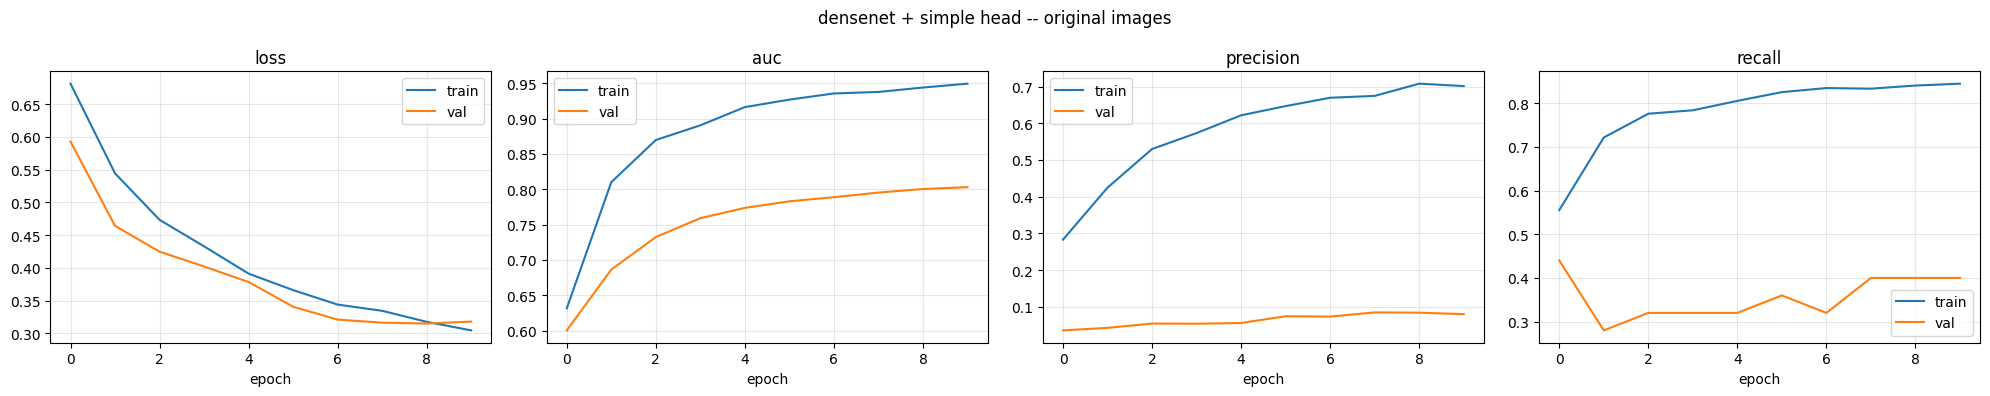

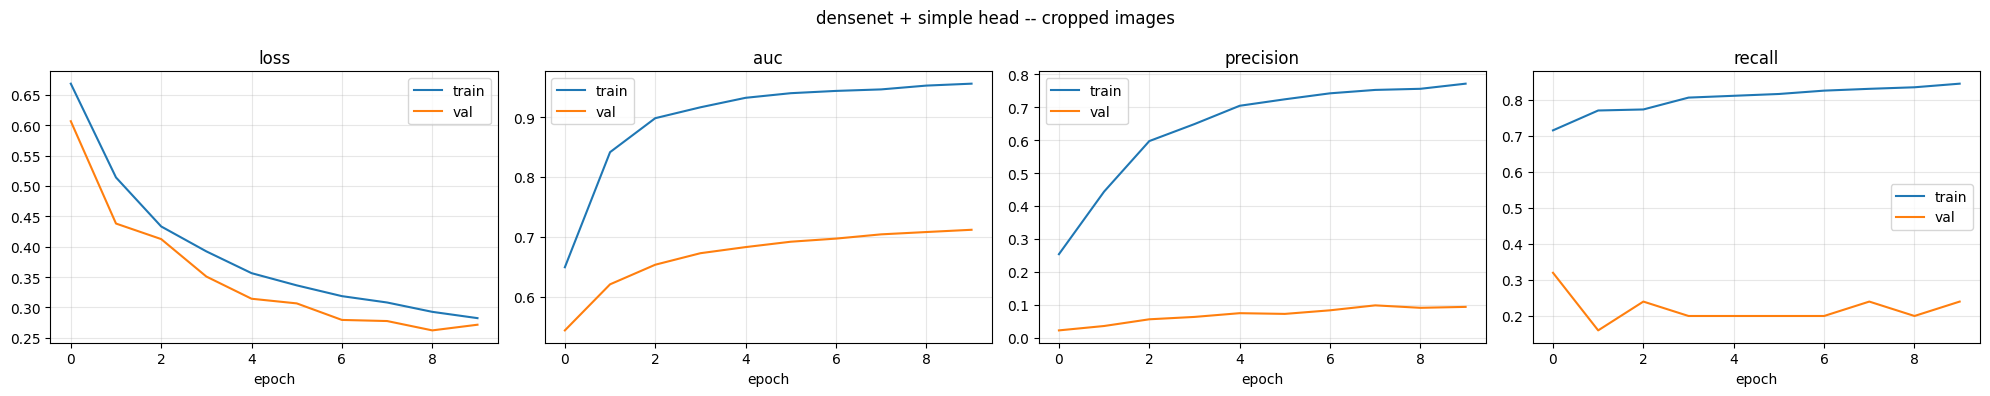

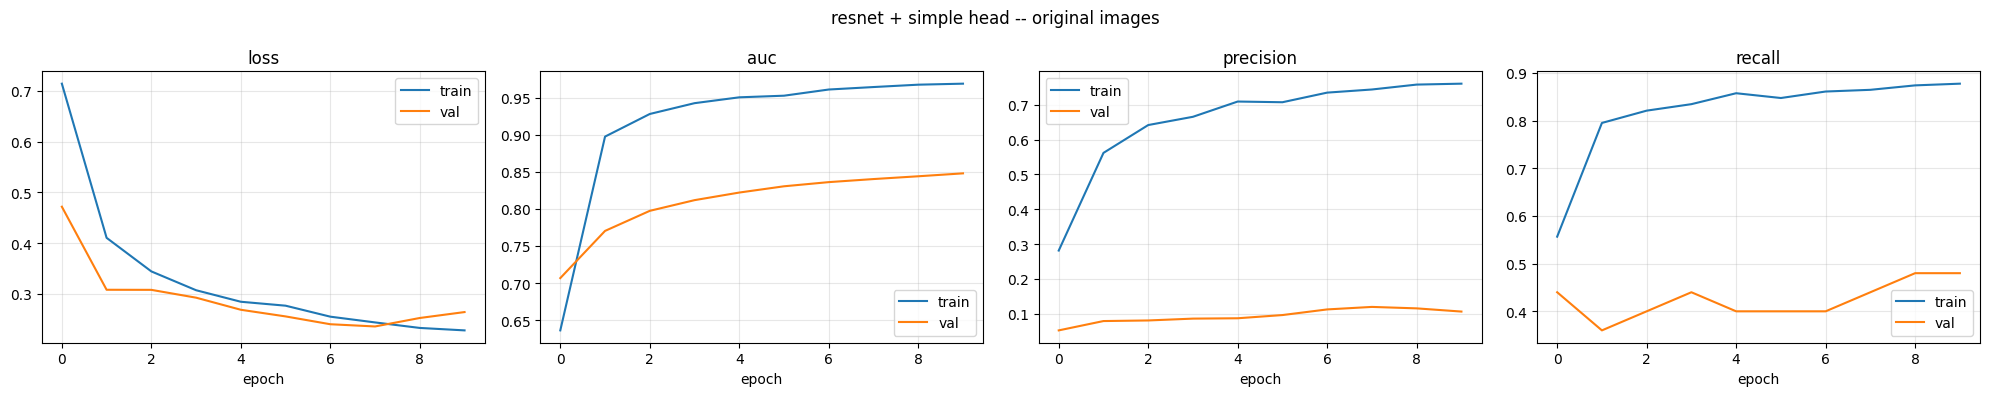

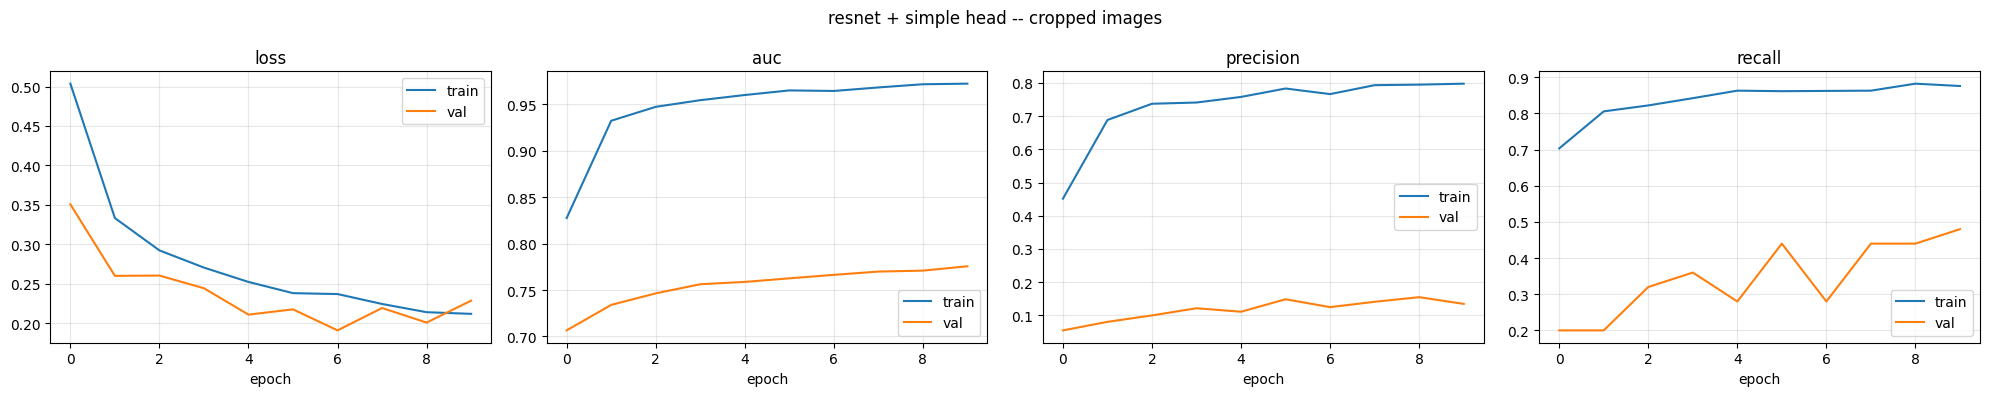

In [49]:
for (backbone_name, source_name), entry in trained.items():
    plot_training_history(entry['history'], f'{backbone_name} + simple head -- {source_name} images')

## Confusion matrices -- all 4 models, side by side

Same validation split (`X_test_orig`/`X_test_crop`, `y_test`) for every model, so
the 4 confusion matrices below are directly comparable to each other.

--- densenet / original (threshold=0.2) ---
              precision    recall  f1-score   support

      benign       1.00      0.60      0.75      1151
   malignant       0.05      0.92      0.09        25

    accuracy                           0.61      1176
   macro avg       0.52      0.76      0.42      1176
weighted avg       0.98      0.61      0.73      1176

--- densenet / cropped (threshold=0.2) ---
              precision    recall  f1-score   support

      benign       0.99      0.62      0.76      1151
   malignant       0.04      0.72      0.07        25

    accuracy                           0.62      1176
   macro avg       0.51      0.67      0.42      1176
weighted avg       0.97      0.62      0.74      1176

--- resnet / original (threshold=0.2) ---
              precision    recall  f1-score   support

      benign       0.99      0.72      0.83      1151
   malignant       0.06      0.80      0.11        25

    accuracy                           0.72      1176

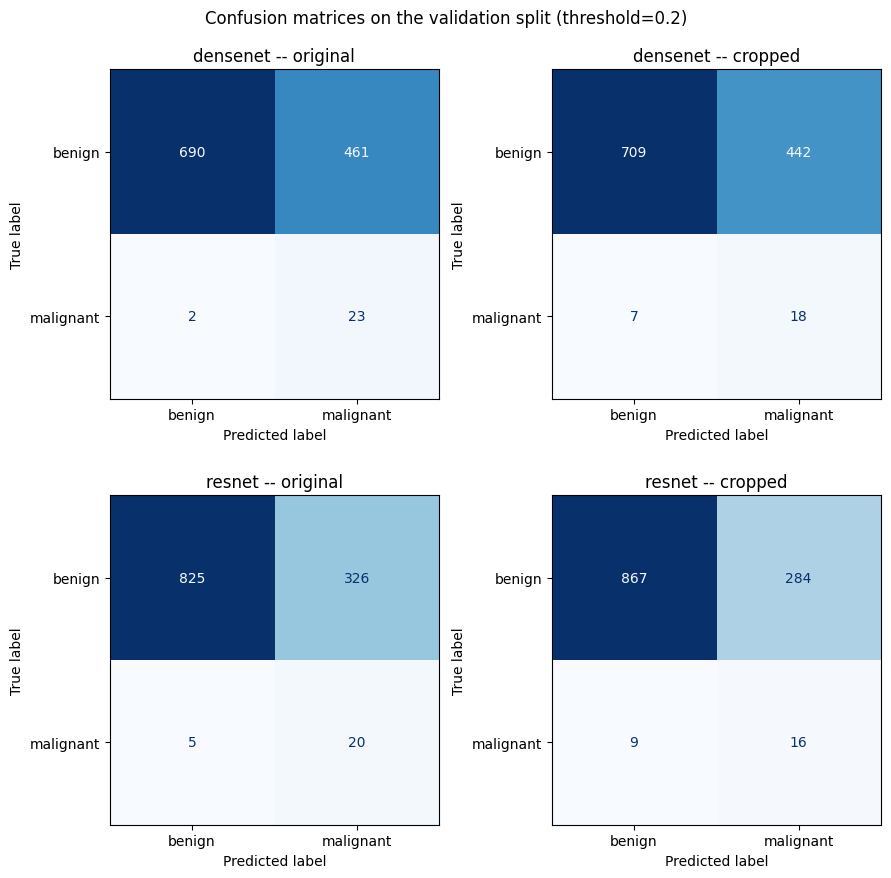

In [50]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

CM_THRESHOLD = 0.2  # adjust if you want a different operating point

fig, axes = plt.subplots(2, 2, figsize=(9, 9))
for ax, (backbone_name, source_name) in zip(axes.ravel(), trained):
    entry = trained[(backbone_name, source_name)]
    model, preprocess_fn = entry['model'], entry['preprocess_fn']
    _, X_test_source, _ = IMAGE_SOURCES[source_name]

    y_prob = model.predict(make_dataset(X_test_source, preprocess_fn), verbose=0).ravel()
    y_pred = (y_prob >= CM_THRESHOLD).astype(int)

    print(f'--- {backbone_name} / {source_name} (threshold={CM_THRESHOLD}) ---')
    print(classification_report(y_test, y_pred, target_names=['benign', 'malignant']))

    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['benign', 'malignant']).plot(
        ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'{backbone_name} -- {source_name}')

fig.suptitle(f'Confusion matrices on the validation split (threshold={CM_THRESHOLD})')
plt.tight_layout()
plt.show()

### Confusion matrices at matched specificity (80%)

The 0.5-threshold matrices above don't compare fairly -- each model lands at a
different specificity (benign true-negative rate) at that fixed cutoff, so any
difference in recall could just be one model trading away more specificity, not
actually being better. Instead, pick each model's own threshold so all 4 land at
the **same 80% specificity**, then compare recall/precision at that matched
operating point.

--- densenet / original (threshold=0.359, specificity=79.93%) ---
              precision    recall  f1-score   support

      benign       0.99      0.80      0.88      1151
   malignant       0.06      0.64      0.12        25

    accuracy                           0.80      1176
   macro avg       0.53      0.72      0.50      1176
weighted avg       0.97      0.80      0.87      1176

--- densenet / cropped (threshold=0.290, specificity=79.93%) ---
              precision    recall  f1-score   support

      benign       0.99      0.80      0.88      1151
   malignant       0.06      0.56      0.10        25

    accuracy                           0.79      1176
   macro avg       0.52      0.68      0.49      1176
weighted avg       0.97      0.79      0.87      1176

--- resnet / original (threshold=0.283, specificity=79.93%) ---
              precision    recall  f1-score   support

      benign       0.99      0.80      0.89      1151
   malignant       0.08      0.76      0.1

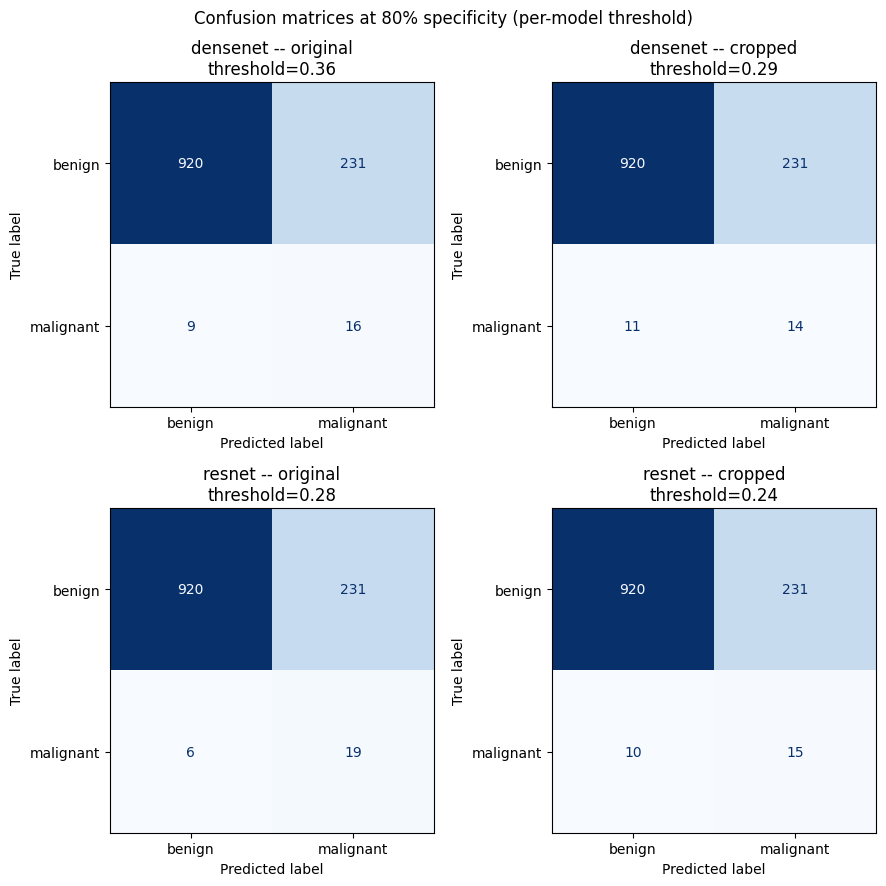

In [51]:
TARGET_SPECIFICITY = 0.80

fig, axes = plt.subplots(2, 2, figsize=(9, 9))
for ax, (backbone_name, source_name) in zip(axes.ravel(), trained):
    entry = trained[(backbone_name, source_name)]
    model, preprocess_fn = entry['model'], entry['preprocess_fn']
    _, X_test_source, _ = IMAGE_SOURCES[source_name]

    y_prob = model.predict(make_dataset(X_test_source, preprocess_fn), verbose=0).ravel()

    # Threshold chosen per model so TARGET_SPECIFICITY of the benign validation
    # images fall below it -- pins specificity to the same value across all 4
    # models, so any difference in recall/precision reflects the model itself
    # rather than each one landing at a different, arbitrary operating point.
    threshold = np.percentile(y_prob[y_test == 0], TARGET_SPECIFICITY * 100)
    y_pred = (y_prob >= threshold).astype(int)

    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    actual_specificity = tn / (tn + fp)

    print(f'--- {backbone_name} / {source_name} (threshold={threshold:.3f}, specificity={actual_specificity:.2%}) ---')
    print(classification_report(y_test, y_pred, target_names=['benign', 'malignant']))

    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['benign', 'malignant']).plot(
        ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'{backbone_name} -- {source_name}\nthreshold={threshold:.2f}')

fig.suptitle(f'Confusion matrices at {TARGET_SPECIFICITY:.0%} specificity (per-model threshold)')
plt.tight_layout()
plt.show()

## Cross-domain check: does the original-trained model rely on borders/rulers?

Same held-out validation images, same model (trained only on **original**
images) -- the only thing that changes between the two rows below is whether the
pixels fed in at test time are the original image or its boundary-localization
crop (rulers, dark vignette, skin-marker ink stripped out).

Each row gets its **own** threshold, picked so that row lands at 80% specificity
on its own predictions -- so this isolates the model's discriminative ability in
each domain (how well it ranks malignant above benign) rather than being
confounded by the raw probability distribution shifting when the input
distribution shifts. If recall (sensitivity) at matched 80% specificity drops
sharply once the crop removes those artifacts, that's evidence the
original-trained model was leaning on them rather than the lesion itself -- a
shortcut, not a real signal.

--- densenet, trained on original images, both rows at 80% specificity ---
  tested on original images (in-domain):     threshold=0.359, recall = 64.00%
  tested on cropped images (out-of-domain):  threshold=0.673, recall = 48.00%  (change = -16.00%)
--- resnet, trained on original images, both rows at 80% specificity ---
  tested on original images (in-domain):     threshold=0.283, recall = 76.00%
  tested on cropped images (out-of-domain):  threshold=0.728, recall = 48.00%  (change = -28.00%)


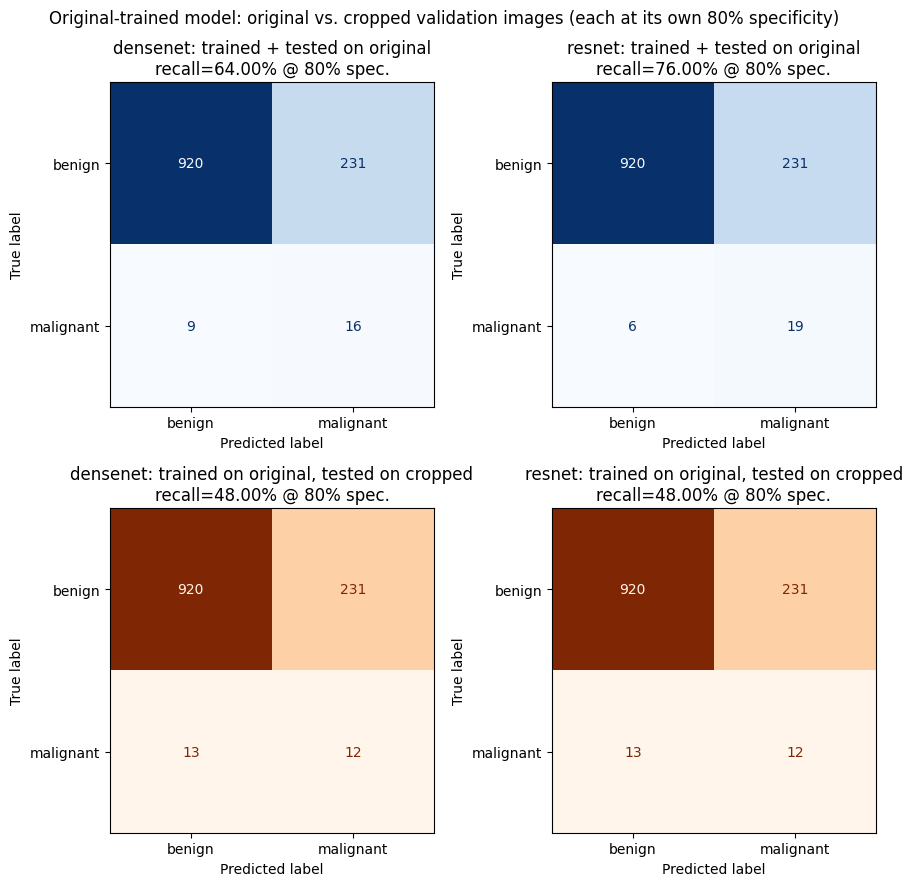

In [52]:
CROSS_DOMAIN_SPECIFICITY = 0.80

fig, axes = plt.subplots(2, 2, figsize=(9, 9))
for col, backbone_name in enumerate(BACKBONES):
    entry = trained[(backbone_name, 'original')]
    model, preprocess_fn = entry['model'], entry['preprocess_fn']

    y_prob_orig = model.predict(make_dataset(X_test_orig, preprocess_fn), verbose=0).ravel()
    y_prob_crop = model.predict(make_dataset(X_test_crop, preprocess_fn), verbose=0).ravel()

    # Each domain gets its own threshold at CROSS_DOMAIN_SPECIFICITY -- isolates
    # the model's discriminative ability (how well it ranks malignant above
    # benign) in each domain, rather than being confounded by the raw probability
    # distribution shifting when the input distribution shifts.
    threshold_orig = np.percentile(y_prob_orig[y_test == 0], CROSS_DOMAIN_SPECIFICITY * 100)
    threshold_crop = np.percentile(y_prob_crop[y_test == 0], CROSS_DOMAIN_SPECIFICITY * 100)

    y_pred_orig = (y_prob_orig >= threshold_orig).astype(int)
    y_pred_crop = (y_prob_crop >= threshold_crop).astype(int)

    cm_orig = confusion_matrix(y_test, y_pred_orig)
    cm_crop = confusion_matrix(y_test, y_pred_crop)
    recall_orig = cm_orig[1, 1] / cm_orig[1].sum()
    recall_crop = cm_crop[1, 1] / cm_crop[1].sum()

    print(f'--- {backbone_name}, trained on original images, both rows at {CROSS_DOMAIN_SPECIFICITY:.0%} specificity ---')
    print(f'  tested on original images (in-domain):     threshold={threshold_orig:.3f}, recall = {recall_orig:.2%}')
    print(f'  tested on cropped images (out-of-domain):  threshold={threshold_crop:.3f}, recall = {recall_crop:.2%}  (change = {recall_crop - recall_orig:+.2%})')

    ConfusionMatrixDisplay(confusion_matrix=cm_orig, display_labels=['benign', 'malignant']).plot(
        ax=axes[0, col], cmap='Blues', colorbar=False)
    axes[0, col].set_title(f'{backbone_name}: trained + tested on original\nrecall={recall_orig:.2%} @ {CROSS_DOMAIN_SPECIFICITY:.0%} spec.')

    ConfusionMatrixDisplay(confusion_matrix=cm_crop, display_labels=['benign', 'malignant']).plot(
        ax=axes[1, col], cmap='Oranges', colorbar=False)
    axes[1, col].set_title(f'{backbone_name}: trained on original, tested on cropped\nrecall={recall_crop:.2%} @ {CROSS_DOMAIN_SPECIFICITY:.0%} spec.')

fig.suptitle(f'Original-trained model: original vs. cropped validation images (each at its own {CROSS_DOMAIN_SPECIFICITY:.0%} specificity)')
plt.tight_layout()
plt.show()

## Does the model score bigger-in-frame lesions higher?

Checks whether the model gives higher melanoma scores to images where the lesion
just takes up more of the picture -- a size-in-frame shortcut, distinct from the
border/ruler-reliance check above. If scores rise as lesions fill more of the
frame, that would also explain why cropping (which makes every lesion fill the
frame) pushed scores up across the board.

This project has no ground-truth ISIC segmentation masks (see the "Boundary
localization crop" section earlier -- the lesion mask here is derived from the
image itself via Otsu thresholding, not a provided ground truth), so lesion
fraction is approximated with the same `boundary_localization_crop` bounding box
already used to make the cropped images, run here on the **original** (uncropped)
validation images -- every *cropped* image is designed to already fill the frame,
so this check isn't meaningful there.

Melanomas genuinely tend to be larger (the "D" in the ABCDE rule), so some
correlation between size and malignancy is legitimate. To separate that from a
shortcut, the benign images are checked on their own: if bigger-in-frame *benign*
lesions also score higher, the model is reacting to size in the frame itself, not
to anything actually malignant. Spearman's rho (not Pearson) is used since it
only cares about ranking, so it isn't thrown off by the skewed probability
distribution -- and with ~1,150 benign images in the validation split, that
benign-only test has far more statistical power than anything involving the ~25
melanomas.

In [53]:
from boundary_localization import boundary_localization_crop

img_h, img_w = X_test_orig.shape[1:3]
lesion_frac = np.empty(len(X_test_orig))
for i, img in enumerate(X_test_orig):
    _, (_, _, bw, bh), _ = boundary_localization_crop(img)
    lesion_frac[i] = (bw * bh) / (img_h * img_w)

print(f'lesion fraction (bounding-box area / frame area): '
      f'min={lesion_frac.min():.2f}, median={np.median(lesion_frac):.2f}, max={lesion_frac.max():.2f}')

lesion fraction (bounding-box area / frame area): min=0.00, median=0.13, max=0.72


--- densenet (trained on original images) ---
  all images:  rho=0.30 (p=1.02e-26, n=1176)
  benign only: rho=0.30 (p=1.01e-25, n=1151)
--- resnet (trained on original images) ---
  all images:  rho=0.40 (p=4.47e-46, n=1176)
  benign only: rho=0.40 (p=3.43e-45, n=1151)


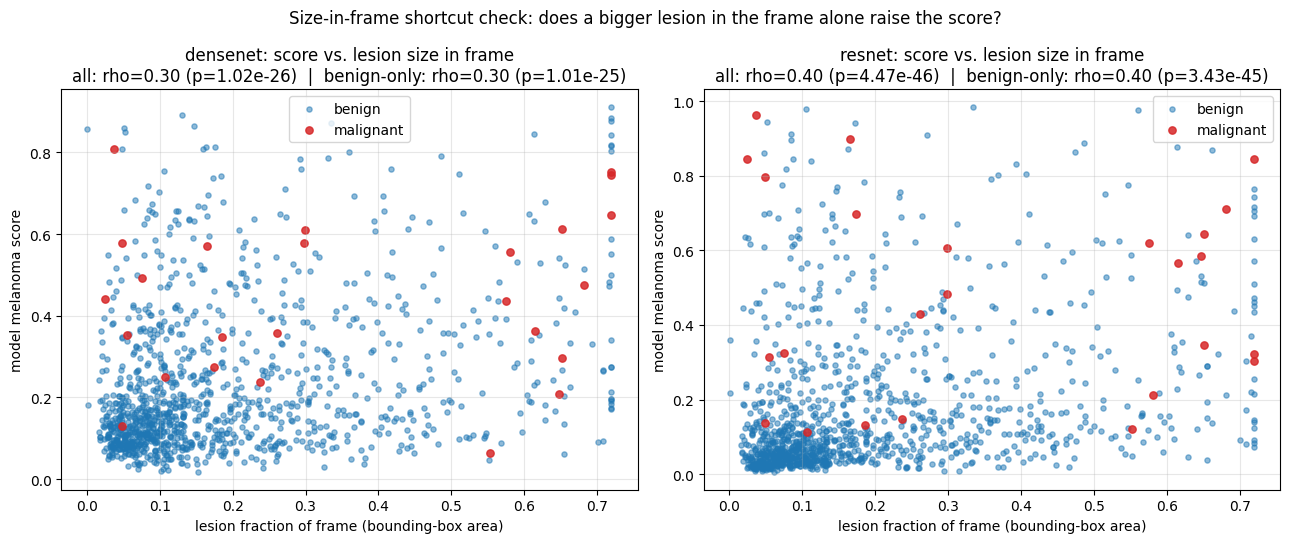

In [54]:
from scipy.stats import spearmanr

benign = y_test == 0

fig, axes = plt.subplots(1, len(BACKBONES), figsize=(6.5 * len(BACKBONES), 5.5))
for ax, backbone_name in zip(axes, BACKBONES):
    entry = trained[(backbone_name, 'original')]
    scores = entry['model'].predict(make_dataset(X_test_orig, entry['preprocess_fn']), verbose=0).ravel()

    rho_all, p_all = spearmanr(lesion_frac, scores)
    rho_b, p_b = spearmanr(lesion_frac[benign], scores[benign])

    print(f'--- {backbone_name} (trained on original images) ---')
    print(f'  all images:  rho={rho_all:.2f} (p={p_all:.3g}, n={len(scores)})')
    print(f'  benign only: rho={rho_b:.2f} (p={p_b:.3g}, n={benign.sum()})')

    ax.scatter(lesion_frac[benign], scores[benign], s=14, alpha=0.5, color='tab:blue', label='benign')
    ax.scatter(lesion_frac[~benign], scores[~benign], s=28, alpha=0.85, color='tab:red', label='malignant')
    ax.set_xlabel('lesion fraction of frame (bounding-box area)')
    ax.set_ylabel('model melanoma score')
    ax.set_title(f'{backbone_name}: score vs. lesion size in frame\n'
                 f'all: rho={rho_all:.2f} (p={p_all:.3g})  |  benign-only: rho={rho_b:.2f} (p={p_b:.3g})')
    ax.legend()
    ax.grid(alpha=0.3)

fig.suptitle('Size-in-frame shortcut check: does a bigger lesion in the frame alone raise the score?')
plt.tight_layout()
plt.show()

## Grad-CAM

`grad_cam.py` (in this folder) implements Grad-CAM for **PyTorch** -- the concept
carries over directly to Keras/TensorFlow via `tf.GradientTape` instead of
PyTorch's hooks + `.backward()`: take the gradient of the predicted class score
with respect to the last conv feature map, use it to weight how much each
channel contributed, and combine the weighted channels into a heatmap.

Each backbone is nested *inside* its model as a single layer, so its internal
conv layers aren't directly on `model.layers` -- `make_gradcam_heatmap` works
around that by building a small model from the backbone's own input to
[conv layer output, backbone's pooled output], then replaying whatever layers
come after it (`Dropout`, `Dense`) as plain calls inside the same tape.

In [55]:
def find_last_conv_layer(inner_model):
    """Last layer with a 4D (batch, H, W, C) output -- the feature map right
    before the inner model's own global-average-pooling head."""
    for layer in reversed(inner_model.layers):
        if len(layer.output.shape) == 4:
            return layer.name
    raise ValueError('no 4D-output layer found in the given model')


def make_gradcam_heatmap(img_array, model, inner_model, last_conv_layer_name):
    """img_array: preprocessed batch, shape (1, IMG_SIZE, IMG_SIZE, 3)."""
    conv_and_pooled = tf.keras.Model(
        inner_model.input,
        [inner_model.get_layer(last_conv_layer_name).output, inner_model.output],
    )
    classifier_layers = model.layers[model.layers.index(inner_model) + 1:]

    with tf.GradientTape() as tape:
        conv_output, pooled_output = conv_and_pooled(img_array)
        tape.watch(conv_output)  # not a Variable, so it needs an explicit watch
        x = pooled_output
        for layer in classifier_layers:
            x = layer(x, training=False)
        class_score = x[:, 0]  # single sigmoid output = malignant score

    grads = tape.gradient(class_score, conv_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))  # one weight per channel

    conv_output = conv_output[0]
    heatmap = conv_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)  # ReLU: only positive contributions matter
    return heatmap.numpy(), float(x[0, 0])


def overlay_gradcam(original_img, heatmap, alpha=0.4):
    """original_img: uint8 RGB array. heatmap: 2D array in [0, 1]."""
    heatmap_resized = cv2.resize(heatmap, (original_img.shape[1], original_img.shape[0]))
    heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)
    return (heatmap_color * alpha + original_img * (1 - alpha)).astype(np.uint8)

### Run Grad-CAM over the validation set's malignant images and save them

Restricted to `test_df`'s malignant rows only (never training images, and never
benign ones) -- one overlay per malignant validation image, per (backbone, source)
combination, saved under `gradcam_outputs/<backbone>_<source>/`.

In [56]:
GRADCAM_DIR = 'gradcam_outputs'
GRADCAM_LIMIT = None  # e.g. 10 for a quick test run; None = every malignant validation image

# Validation-only, malignant-only subset -- boolean mask aligns positionally across
# test_df/X_test_orig/X_test_crop/y_test since they were all sliced by the same test_idx.
malignant_mask = y_test == 1
malignant_df = test_df[malignant_mask]
malignant_images = {
    'original': X_test_orig[malignant_mask],
    'cropped': X_test_crop[malignant_mask],
}
print(f'{malignant_mask.sum()} malignant images in the validation split')

for (backbone_name, source_name), entry in trained.items():
    model, base, preprocess_fn = entry['model'], entry['base'], entry['preprocess_fn']
    last_conv_layer_name = find_last_conv_layer(base)

    df = malignant_df if GRADCAM_LIMIT is None else malignant_df.iloc[:GRADCAM_LIMIT]
    images = malignant_images[source_name] if GRADCAM_LIMIT is None else malignant_images[source_name][:GRADCAM_LIMIT]

    out_dir = os.path.join(GRADCAM_DIR, f'{backbone_name}_{source_name}')
    os.makedirs(out_dir, exist_ok=True)

    for i, (image_name, img) in enumerate(zip(df['image_name'], images)):
        img_batch = preprocess_fn(np.expand_dims(img.astype(np.float32), axis=0))
        heatmap, prob = make_gradcam_heatmap(img_batch, model, base, last_conv_layer_name)
        overlay = overlay_gradcam(img, heatmap)
        Image.fromarray(overlay).save(os.path.join(out_dir, f'{image_name}_prob{prob:.2f}.jpg'), quality=90)
        if (i + 1) % 500 == 0:
            print(f'{backbone_name}/{source_name}: {i + 1}/{len(images)} saved')

    print(f'--- {backbone_name}/{source_name}: done -- {len(os.listdir(out_dir))} images in {out_dir}/ ---')

25 malignant images in the validation split
--- densenet/original: done -- 48 images in gradcam_outputs/densenet_original/ ---
--- densenet/cropped: done -- 46 images in gradcam_outputs/densenet_cropped/ ---
--- resnet/original: done -- 47 images in gradcam_outputs/resnet_original/ ---
--- resnet/cropped: done -- 42 images in gradcam_outputs/resnet_cropped/ ---


## Zip everything and upload to Google Drive

In [57]:
GRADCAM_ZIP = 'gradcam_outputs.zip'
DRIVE_GRADCAM_ZIP = '/content/drive/MyDrive/gradcam_outputs.zip'

with zipfile.ZipFile(GRADCAM_ZIP, 'w', zipfile.ZIP_DEFLATED) as zf:
    for root, _, filenames in os.walk(GRADCAM_DIR):
        for filename in sorted(filenames):
            fpath = os.path.join(root, filename)
            zf.write(fpath, arcname=os.path.relpath(fpath, GRADCAM_DIR))
print(f'wrote {GRADCAM_ZIP} ({os.path.getsize(GRADCAM_ZIP) / 1e6:.0f} MB)')

if os.path.isdir('/content/drive/MyDrive'):
    shutil.copy(GRADCAM_ZIP, DRIVE_GRADCAM_ZIP)
    print(f'copied to Google Drive as {os.path.basename(DRIVE_GRADCAM_ZIP)}')
else:
    print('not on Colab / no Drive mounted -- gradcam_outputs.zip is sitting locally next to this notebook')

wrote gradcam_outputs.zip (1 MB)
copied to Google Drive as gradcam_outputs.zip
